# Paracetamol: symmetry-first clustering

The torsional states of paracetamol, found with the default `t_hdbscan` workflow:

1. **enumerate the molecular symmetry** -- RDKit matches the molecule against itself;
2. **build a symmetry-aware torsional distance** -- the distance between two frames is the minimum
   over the symmetry-equivalent ways of *labelling* their atoms;
3. **fit HDBSCAN** on that distance;
4. **classify every frame** with the same distance and an absolute 20-neighbour vote (18 of 20).

**Relabelling is not motion.** A symmetry operation renames atoms: after the ring flip, the atom
called C5 is the one that used to be called C10. Nothing moves, so a frame and its relabelled
description are the same configuration, and the distance between them is zero. Rotating the ring
by 180 degrees is a different thing -- a physical motion that changes the coordinates -- and
whether the sampled ensemble does that is a question about the data, not about the labels.

**A cluster is a density basin, not a metastable state.** Nothing here looks at time.

The previous version of this page clustered first and merged symmetry-related clusters
afterwards; it is kept unchanged under
[Tutorial / archived / 0.6.4](https://csy0000.github.io/MD-tools/tutorial/archived/0.6.4/paracetamol/clustering/). The two
workflows are compared on the same frames in [the comparison notebook](https://csy0000.github.io/MD-tools/tutorial/paracetamol/analysis/clustering-comparison/).

**Needs the analysis environment** (`scikit-learn`, `rdkit`, `mdtraj`): see
[Installing](https://csy0000.github.io/MD-tools/install/#5-optional-the-analysis-environment).

In [1]:
import sys, pathlib, time, tracemalloc
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] / "_analysis"))   # docs/tutorial/_analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md
from IPython.display import SVG, Image, display
import tutorial_data as td

# Where the runs are. NOT defaulted, and the resolved path is deliberately NOT printed: these
# notebooks are committed WITH their outputs, and an echoed absolute path would put one machine's
# layout into a published file.
print("tutorial runs:", "found" if td.runs_root().is_dir() else "MISSING")
import importlib.util, md_tools
# The version string alone would be misleading: this page uses the symmetry-first analysis, which
# no released version carries yet, so the page says which code it ran on.
symmetry_first = importlib.util.find_spec("md_tools.analysis._symmetry_metric") is not None
print("md-tools", md_tools.__version__,
      "+ the unreleased symmetry-first analysis" if symmetry_first else "(no symmetry-first analysis)")

tutorial runs: found
md-tools 0.6.4 + the unreleased symmetry-first analysis


## 1. The molecule, its atom indices and the selected torsions

The reference molecule is the SDF the system was built from. Its atom indices are the ones every
quadruplet below refers to. The three selected torsions are the same as in the PMF notebook:

| name | atoms | central bond |
|---|---|---|
| `omega` | 0-1-3-4 | the amide C1-N3 |
| `aryl` | 1-3-4-5 | N3-C4, the bond joining the amide to the ring |
| `phenol` | 6-7-8-17 | C7-O8, the hydroxyl rotation |

CC(=O)Nc1ccc(O)cc1 | 20 atoms


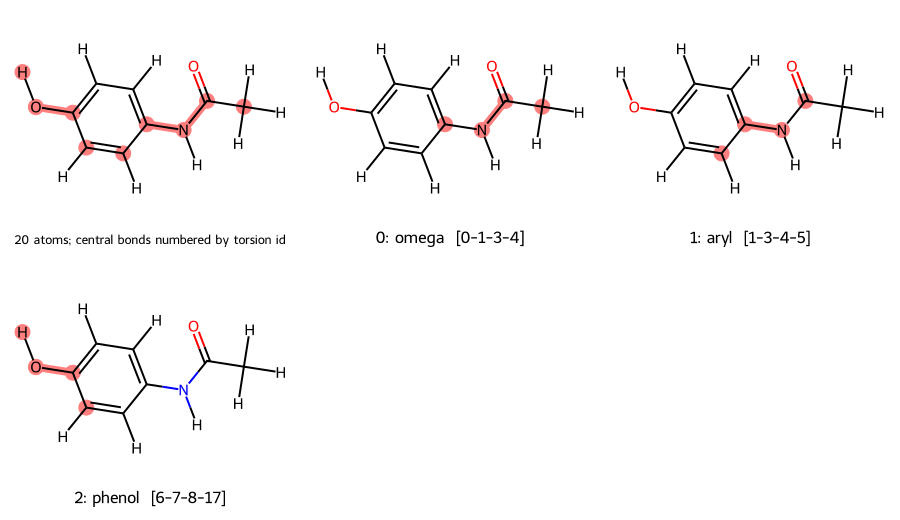

index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
element,C,C,O,N,C,C,C,C,O,C,C,H,H,H,H,H,H,H,H,H
bonded to,"[1, 11, 12, 13]","[0, 2, 3]",[1],"[1, 4, 14]","[3, 5, 10]","[4, 6, 15]","[5, 7, 16]","[6, 8, 9]","[7, 17]","[7, 10, 18]","[9, 4, 19]",[0],[0],[0],[3],[5],[6],[8],[9],[10]


In [2]:
from rdkit import Chem
from md_tools.analysis import TorsionDefinitions, draw_torsions

mol = Chem.SDMolSupplier(str(td.run_dir("PARA-REST2") / "build/TYL.sdf"), removeHs=False)[0]
PARA_TORSIONS = {"omega": (0, 1, 3, 4), "aryl": (1, 3, 4, 5), "phenol": (6, 7, 8, 17)}
definitions = TorsionDefinitions(quads=tuple(PARA_TORSIONS.values()), names=tuple(PARA_TORSIONS),
                                 indexing="zero-based", units="radian")
names = list(definitions.names)

atoms = pd.DataFrame([{"index": a.GetIdx(), "element": a.GetSymbol(),
                       "bonded to": [n.GetIdx() for n in a.GetNeighbors()]}
                      for a in mol.GetAtoms()]).set_index("index")
print(Chem.MolToSmiles(Chem.RemoveHs(mol)), "|", mol.GetNumAtoms(), "atoms")
draw_torsions(mol, definitions, output="torsions.svg")
display(SVG(filename="torsions.svg"))
atoms.T

## 2. Enumerating the symmetry: RDKit matches the molecule against itself

A symmetry operation is an atom permutation that preserves the chemical graph -- element, bond
order, formal charge, isotope and any specified stereochemistry. RDKit finds every one by matching
the molecule against **itself** with `uniquify=False`, which returns every isomorphism of the graph
onto itself, for the whole molecule: rings, methyl groups, anything.

`enumerate_symmetry` does exactly that on a copy with atom-map numbers cleared, re-verifies each
match as a bond- and element-preserving bijection, puts the identity first, and asks for one more
match than its cap so that a truncated search is detected and **refused** rather than used.
Each returned tuple reads "atom *i* is mapped to atom `p[i]`".

In [3]:
from md_tools.analysis import enumerate_symmetry

raw = mol.GetSubstructMatches(mol, uniquify=False, useChirality=True, maxMatches=1000)
print(f"RDKit self-matches: {len(raw)}")
for p in raw[:2] + raw[6:8]:
    moved = {i: j for i, j in enumerate(p) if i != j}
    print(" ", p, "  moved:", moved if moved else "nothing (identity)")

enumeration = enumerate_symmetry(mol)
print()
print(enumeration.describe())

RDKit self-matches: 12
  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19)   moved: nothing (identity)
  (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 12, 14, 15, 16, 17, 18, 19)   moved: {12: 13, 13: 12}
  (0, 1, 2, 3, 4, 10, 9, 7, 8, 6, 5, 11, 12, 13, 14, 19, 18, 17, 16, 15)   moved: {5: 10, 6: 9, 9: 6, 10: 5, 15: 19, 16: 18, 18: 16, 19: 15}
  (0, 1, 2, 3, 4, 10, 9, 7, 8, 6, 5, 11, 13, 12, 14, 19, 18, 17, 16, 15)   moved: {5: 10, 6: 9, 9: 6, 10: 5, 12: 13, 13: 12, 15: 19, 16: 18, 18: 16, 19: 15}

{'n_automorphisms': 12, 'n_atoms': 20, 'use_chirality': True, 'cap': 200000, 'complete': True, 'rejected_by_stereo_check': 0, 'method': 'RDKit self-substructure match, uniquify=False, whole molecule (not restricted to rings); every match re-verified as a bond- and element-preserving bijection'}


Twelve permutations: the three methyl hydrogens (11, 12, 13) in any of 3! = 6 orders, times the
ring flip that exchanges the two sides of the ring -- C5 with C10, C6 with C9, and their hydrogens
H15 with H19 and H16 with H18. The amide, the ring's para axis (C4 and C7) and the hydroxyl stay
where they are.

## 3. What an enumeration does to the torsions

A torsion is measured through four NAMED atoms. Relabelling the atoms therefore changes which
quadruplet a column measures. Under the ring flip `aryl` (1-3-4-**5**) becomes 1-3-4-**10**: the same
central bond, measured to the other ortho carbon. `phenol` (**6**-7-8-17) becomes **9**-7-8-17.
Neither image is among the selected torsions, so the flip does not even act on the table as it
stands.

`SymmetricTorsionDescriptor` closes the selection under the group: every image of a selected
torsion becomes a column, recomputed from coordinates. Each **orbit** -- a set of columns the
operations exchange -- carries the total weight of the torsions selected in it, split equally,
so the ring orientation counts once in the distance and not twice.

In [4]:
from md_tools.analysis import SymmetricTorsionDescriptor, draw_symmetry_operation

descriptor = SymmetricTorsionDescriptor(mol, definitions)
columns = pd.DataFrame([{"column": n, "atoms": "-".join(map(str, q)), "weight": w,
                         "origin": ("selected" if o["kind"] == "selected"
                                    else f"image of {o['image_of']}")}
                        for n, q, w, o in zip(descriptor.names, descriptor.quads,
                                              descriptor.column_weights, descriptor.origin)])
print("orbits:", [[descriptor.names[c] for c in orbit] for orbit in descriptor.orbits])
print("group closure verified:", descriptor.group_closure_verified,
      "| isometry verified:", descriptor.isometry_verified)
columns

orbits: [['omega'], ['aryl', 'aryl@1-3-4-10'], ['phenol', 'phenol@9-7-8-17']]
group closure verified: True | isometry verified: True


,column,atoms,weight,origin
0,omega,0-1-3-4,1.0,selected
1,aryl,1-3-4-5,0.5,selected
2,phenol,6-7-8-17,0.5,selected
3,aryl@1-3-4-10,1-3-4-10,0.5,image of aryl
4,phenol@9-7-8-17,9-7-8-17,0.5,image of phenol


operation 1 exchanges (atom pairs): [(5, 10), (6, 9), (15, 19), (16, 18)]


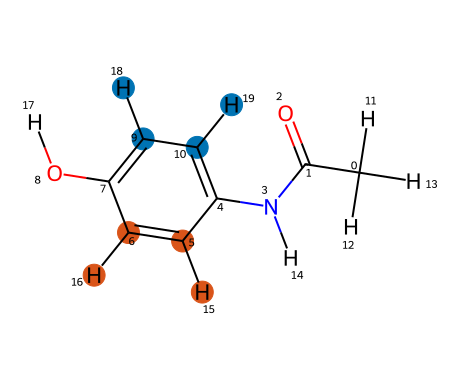

In [5]:
info = draw_symmetry_operation(descriptor, 1, output="ring_exchange.png")
print("operation 1 exchanges (atom pairs):", info["exchanged_pairs"])
display(Image(filename="ring_exchange.png"))

### The table of original and transformed quadruplets

For each distinct operation, what every column of the closed descriptor becomes. `sigma` is the
column of the original frame that supplies each column of the relabelled one.

In [6]:
rows = []
for op in descriptor.operations:
    for c, q in enumerate(descriptor.quads):
        image = tuple(op.atom_permutation[i] for i in q)
        rows.append({"operation": ("identity" if op.is_identity else f"op {op.index}: ring exchange"),
                     "column": descriptor.names[c],
                     "original quadruplet": "-".join(map(str, q)),
                     "transformed quadruplet": "-".join(map(str, image)),
                     "read from column": descriptor.names[op.sigma[c]]})
pd.DataFrame(rows)

,operation,column,original quadruplet,transformed quadruplet,read from column
0,identity,omega,0-1-3-4,0-1-3-4,omega
1,identity,aryl,1-3-4-5,1-3-4-5,aryl
2,identity,phenol,6-7-8-17,6-7-8-17,phenol
3,identity,aryl@1-3-4-10,1-3-4-10,1-3-4-10,aryl@1-3-4-10
4,identity,phenol@9-7-8-17,9-7-8-17,9-7-8-17,phenol@9-7-8-17
5,op 1: ring exchange,omega,0-1-3-4,0-1-3-4,omega
6,op 1: ring exchange,aryl,1-3-4-5,1-3-4-10,aryl@1-3-4-10
7,op 1: ring exchange,phenol,6-7-8-17,9-7-8-17,phenol@9-7-8-17
8,op 1: ring exchange,aryl@1-3-4-10,1-3-4-10,1-3-4-5,aryl
9,op 1: ring exchange,phenol@9-7-8-17,9-7-8-17,6-7-8-17,phenol


### Why the six methyl-hydrogen permutations collapse

No selected torsion contains a methyl hydrogen, so permuting H11, H12 and H13 changes no column:
all six methyl permutations act on the descriptor exactly as the identity does, and the six
"methyl permutation x ring flip" act exactly as the flip does. They are real symmetries of the
molecule and they are **one operation each** as far as this distance is concerned. Keeping all
twelve would only repeat each comparison six times.

In [7]:
sigma_to_op = {op.sigma: op.index for op in descriptor.operations}
collapse = []
for p in enumeration.permutations:
    image_cols = []
    for q in descriptor.quads:
        img = tuple(p[i] for i in q)
        rev = tuple(reversed(img))
        image_cols.append(next(k for k, qq in enumerate(descriptor.quads) if qq in (img, rev)))
    collapse.append({"permutation of H11-H13": tuple(p[11:14]),
                     "ring flipped": p[5] == 10,
                     "action on the descriptor (sigma)": tuple(image_cols),
                     "descriptor operation": sigma_to_op[tuple(image_cols)]})
pd.DataFrame(collapse)

,permutation of H11-H13,ring flipped,action on the descriptor (sigma),descriptor operation
0,"(11, 12, 13)",False,"(0, 1, 2, 3, 4)",0
1,"(11, 13, 12)",False,"(0, 1, 2, 3, 4)",0
2,"(12, 11, 13)",False,"(0, 1, 2, 3, 4)",0
3,"(12, 13, 11)",False,"(0, 1, 2, 3, 4)",0
4,"(13, 11, 12)",False,"(0, 1, 2, 3, 4)",0
5,"(13, 12, 11)",False,"(0, 1, 2, 3, 4)",0
6,"(11, 12, 13)",True,"(0, 3, 4, 1, 2)",1
7,"(11, 13, 12)",True,"(0, 3, 4, 1, 2)",1
8,"(12, 11, 13)",True,"(0, 3, 4, 1, 2)",1
9,"(12, 13, 11)",True,"(0, 3, 4, 1, 2)",1


## 4. One real pair of frames

The trajectory is the 1 us cMD run, every 25th frame -- 4000 frames, as in the PMF notebook. The
stored torsions are computed by `mdtraj`; the descriptor reuses them and recomputes only the two
added columns from the coordinates, after checking that the stored columns agree with the
coordinates under the verified atom mapping. The molecule is made whole across the periodic
box before any dihedral is computed.

In [8]:
from md_tools.analysis import verify_atom_mapping

cmd = td.solute("PARA-1us", stride=25)
tors = md.compute_dihedrals(cmd, list(PARA_TORSIONS.values()))
mapping, why = verify_atom_mapping(mol, [(b[0].index, b[1].index) for b in cmd.topology.bonds],
                                   [a.element.symbol for a in cmd.topology.atoms])
print(f"{tors.shape[0]} frames | atom mapping:",
      "identity" if mapping == list(range(mol.GetNumAtoms())) else mapping, "|", why)

closed = descriptor.closed_angles(tors, coordinates=cmd, atom_mapping=mapping)
print(f"stored columns agree with the coordinates to {descriptor.stored_agreement_:.2e} rad")
shift = np.rad2deg(np.angle(np.exp(1j * (closed[:, 3] - closed[:, 1] - np.pi))))
print(f"aryl@1-3-4-10 minus (aryl + 180 deg): mean {shift.mean():+.2f}, sd {shift.std():.2f}, "
      f"largest {np.abs(shift).max():.1f} deg  <- why the image is recomputed, not shifted")

4000 frames | atom mapping: identity | identity verified: elements and the full bond graph agree under this mapping


stored columns agree with the coordinates to 2.67e-07 rad
aryl@1-3-4-10 minus (aryl + 180 deg): mean +0.09, sd 7.09, largest 25.4 deg  <- why the image is recomputed, not shifted


Two frames picked from the data, not constructed: frame *x* is the first frame of the run, and
frame *y* is the frame closest to *x* once *y* is relabelled by the ring exchange, among frames
whose **unrelabelled** description is far from *x*. Their stored torsions, in degrees:

In [9]:
X = descriptor.embed(closed)
D_id = np.linalg.norm(X - X[0], axis=1)                                  # identity only
Xflip = descriptor.embed(descriptor.transform(closed, 1))
D_flip = np.linalg.norm(Xflip - X[0], axis=1)                            # y relabelled
candidates = np.flatnonzero(D_id > 1.0)
i, j = 0, int(candidates[np.argmin(D_flip[candidates])])
pair = pd.DataFrame(np.rad2deg(closed[[i, j]]), columns=descriptor.names,
                    index=[f"x = frame {i}", f"y = frame {j}"]).round(1)
pair

,omega,aryl,phenol,aryl@1-3-4-10,phenol@9-7-8-17
x = frame 0,155.2,-153.6,-16.4,29.6,167.1
y = frame 2324,158.0,28.9,166.4,-152.4,-17.4


Read naively, *x* and *y* differ by about 180 degrees in both `aryl` and `phenol`. But *y*'s
`aryl@1-3-4-10` is close to *x*'s `aryl`, and *y*'s `phenol@9-7-8-17` is close to *x*'s `phenol`:
*y* is the same conformer, written with the ring's two sides named the other way round.

The complete enumeration table for this pair: every operation `g` applied to *x* and every `h`
applied to *y*, with the Euclidean distance between the embeddings
`Phi = (sqrt(w) cos, sqrt(w) sin)` per column. The one-sided search compares *x* with each
relabelling of *y*; the two-sided table is the definition, and its minimum is the same number.

In [10]:
rows = descriptor.pair_table(closed[i], closed[j])
one_sided = pd.DataFrame([{"g applied to y": ("identity" if r["is_identity"] else "ring exchange"),
                           **{f"{n} of g y": round(float(np.rad2deg(v)), 1)
                              for n, v in zip(descriptor.names, r["theta_gy"])},
                           "|Phi(x) - Phi(g y)|": round(r["distance"], 4)} for r in rows])
d_sym, op = descriptor.distance(closed[i], closed[j])
d_two, (g, h) = descriptor.exhaustive_distance(closed[i], closed[j])
print(f"d_sym (one-sided) = {d_sym:.6f}, minimising operation {op}")
print(f"d_sym (two-sided) = {d_two:.6f}, minimising pair (g, h) = ({g}, {h})")
one_sided

d_sym (one-sided) = 0.053563, minimising operation 1
d_sym (two-sided) = 0.053563, minimising pair (g, h) = (0, 1)


,g applied to y,omega of g y,aryl of g y,phenol of g y,aryl@1-3-4-10 of g y,phenol@9-7-8-17 of g y,|Phi(x) - Phi(g y)|
0,identity,158.0,28.9,166.4,-152.4,-17.4,2.8278
1,ring exchange,158.0,-152.4,-17.4,28.9,166.4,0.0536


In [11]:
label = {0: "identity", 1: "ring exchange"}
two = pd.DataFrame(index=[f"g={label[g]}" for g in range(2)], columns=[f"h={label[h]}" for h in range(2)],
                   dtype=float)
for gg in range(2):
    for hh in range(2):
        gx = descriptor.embed(descriptor.transform(closed[[i]], gg))
        hy = descriptor.embed(descriptor.transform(closed[[j]], hh))
        two.iloc[gg, hh] = float(np.linalg.norm(gx - hy))
print("two-sided enumeration: |Phi(g x) - Phi(h y)|")
two.style.format("{:.4f}").highlight_min(axis=None, props="font-weight: bold; background-color: #ffe08a")

two-sided enumeration: |Phi(g x) - Phi(h y)|


,h=identity,h=ring exchange
g=identity,2.8278,0.0536
g=ring exchange,0.0536,2.8278


The minimum appears twice in the two-sided table -- (identity, ring exchange) and
(ring exchange, identity) -- because relabelling **both** frames by the same operation changes
nothing: the action is an isometry. That is why the one-sided search over `h` alone is exact here,
and the descriptor checks the two conditions it rests on (closure and equal weights within each
orbit) when it is built. Ties go to the earlier operation, deterministically.

The relabelling is checked against geometry, not just against the table: renaming *y*'s atoms and
measuring every column again from the coordinates gives exactly the transformed row.

In [12]:
flip = descriptor.operations[1].atom_permutation
relabelled_xyz = cmd.xyz[[j]][:, list(flip), :]   # atom k now sits where atom flip[k] sat
measured = descriptor.closed_angles(None, coordinates=relabelled_xyz,
                                    box_vectors=cmd.unitcell_vectors[[j]],
                                    atom_mapping=list(range(mol.GetNumAtoms())),
                                    topology=cmd.topology)
print("relabelled-and-remeasured minus transformed (rad):",
      np.round(np.angle(np.exp(1j * (measured[0] - descriptor.transform(closed[[j]], 1)[0]))), 7))

relabelled-and-remeasured minus transformed (rad): [ 1.e-07  0.e+00  0.e+00 -0.e+00 -0.e+00]


## 5. HDBSCAN on the symmetry-aware distance

`t_hdbscan` with the molecule, the torsion definitions, the trajectory and the atom mapping does
all four steps. The distance is a minimum over relabellings, which is not Euclidean in any fixed
embedding, so it is handed to HDBSCAN as an **exact dense matrix** -- never squeezed into a
Euclidean KD-tree. For 4000 frames one copy is 128 MB; above `max_precomputed_frames` (10000)
the fit refuses and names the subset route (`resampling=N`) instead of changing the metric.

In [13]:
from md_tools.analysis import t_hdbscan

tracemalloc.start()
start = time.perf_counter()
fit = t_hdbscan(tors, molecule=mol, torsion_definitions=definitions,
                coordinates=cmd, atom_mapping=mapping).fit()
elapsed = time.perf_counter() - start
peak = tracemalloc.get_traced_memory()[1]
tracemalloc.stop()
summary = fit.summary()
print(f"route {summary['route']}: {summary['n_fit_frames']} frames fitted, "
      f"{summary['n_clusters']} clusters")
print(f"min_cluster_size {summary['settings']['min_cluster_size']}, "
      f"min_samples {summary['settings']['min_samples']}")
print(f"distance matrix: {summary['settings']['precomputed_bytes_per_copy'] / 2**20:.0f} MiB per copy")
print(f"wall time {elapsed:.1f} s | peak traced allocation {peak / 2**20:.0f} MiB "
      f"(numpy and Python; measured on 4 pinned cores)")
print(f"density proxy agrees with HDBSCAN's own noise verdict on "
      f"{100 * summary['density_proxy_agreement']:.2f} % of the fitted frames")

route symmetry-first: 4000 frames fitted, 2 clusters
min_cluster_size 40, min_samples 40
distance matrix: 122 MiB per copy
wall time 9.9 s | peak traced allocation 435 MiB (numpy and Python; measured on 4 pinned cores)
density proxy agrees with HDBSCAN's own noise verdict on 100.00 % of the fitted frames


The wall time above is the FIRST fit in this kernel, under `tracemalloc`, so it includes imports and tracing overhead. Warm timings, median of three repetitions for each workflow, are in the [comparison notebook](https://csy0000.github.io/MD-tools/tutorial/paracetamol/analysis/clustering-comparison/).

### Is one state a possible answer here?

`allow_single_cluster` defaults to **True** (sklearn's default is False, which makes a unimodal
ensemble impossible to report as one state). Checked both ways:

In [14]:
for flag in (True, False):
    s = t_hdbscan(tors, molecule=mol, torsion_definitions=definitions, coordinates=cmd,
                  atom_mapping=mapping, allow_single_cluster=flag).fit().summary()
    print(f"allow_single_cluster={flag!s:5s} -> {s['n_clusters']} clusters")

allow_single_cluster=True  -> 2 clusters


allow_single_cluster=False -> 2 clusters


## 6. Assigning frames: 18 of 20

After the fit every frame is classified by its 20 nearest **clustered** frames under the same
symmetry-aware distance, itself excluded. It joins the winning cluster when the winner holds at
least 90 % of the votes -- **18 of 20 assigns, 17 of 20 does not**. With fewer than 20 eligible
neighbours the denominator is their actual number (`k_effective`, reported). Two kinds of
unassigned frame, kept apart:

* **-2, density noise**: the frame's neighbourhood is thinner than any clustered frame's, under
  the same distance. Takes precedence.
* **-1, ambiguous**: fewer than 18 of 20 neighbours agree. This describes the sample around the
  frame; it is **not** evidence of a free-energy barrier.

In [15]:
votes = pd.Series(fit.n_winner_).value_counts().sort_index(ascending=False)
print("winning votes (of k_effective =", sorted(set(fit.k_effective_.tolist())), "): frames")
print(votes.to_string())
low = np.flatnonzero(fit.n_winner_ < 18)
print(f"\nframes below 18 of 20: {low.size}; their final labels: {fit.labels_[low].tolist()}")

populations = pd.DataFrame(
    [{"label": c, "kind": "cluster", "frames": int((fit.labels_ == c).sum()),
      "mass": fit.cluster_mass_[c]} for c in range(fit.n_clusters_)]
    + [{"label": -2, "kind": "density noise", "frames": int((fit.labels_ == -2).sum()),
        "mass": fit.noise_mass_},
       {"label": -1, "kind": "ambiguous", "frames": int((fit.labels_ == -1).sum()),
        "mass": fit.ambiguous_mass_}])
print(f"\nsum of masses: {populations['mass'].sum():.12f}")
populations

winning votes (of k_effective = [20] ): frames
20    3995
18       1
17       2
14       1
11       1

frames below 18 of 20: 4; their final labels: [-2, -2, -2, -2]

sum of masses: 1.000000000000


,label,kind,frames,mass
0,0,cluster,2056,0.51400
1,1,cluster,1935,0.48375
2,-2,density noise,9,0.00225
3,-1,ambiguous,0,0.00000


Every frame below 18 votes is also density noise, which takes precedence -- so on this
trajectory nothing is labelled ambiguous. That is a finding about these data, not a property of
the rule: on an ensemble with a populated region between two basins the two codes separate.

## 7. What the clusters contain

A cluster can hold one conformer written in two labellings, so a histogram of the raw `aryl`
column of one cluster shows two peaks that are one geometry. Each member is therefore written in
the labelling closest to the cluster's representative frame (`aligned_angles`); the relabelling
moves no atom, and which operation was used is returned per frame.

In [16]:
from md_tools.analysis import group_name

groups = {group_name(c): c for c in range(fit.n_clusters_)}
reps = fit.representatives()
aligned = {name: fit.aligned_angles(c) for name, c in groups.items()}
for name, c in groups.items():
    used = np.bincount(aligned[name]["operations"], minlength=2)
    print(f"cluster {name}: {int((fit.labels_ == c).sum())} frames, mass {fit.cluster_mass_[c]:.4f}, "
          f"representative frame {reps[c]} | members written as-is {used[0]}, relabelled {used[1]}")

cluster A: 2056 frames, mass 0.5140, representative frame 453 | members written as-is 932, relabelled 1124
cluster B: 1935 frames, mass 0.4838, representative frame 1340 | members written as-is 1096, relabelled 839


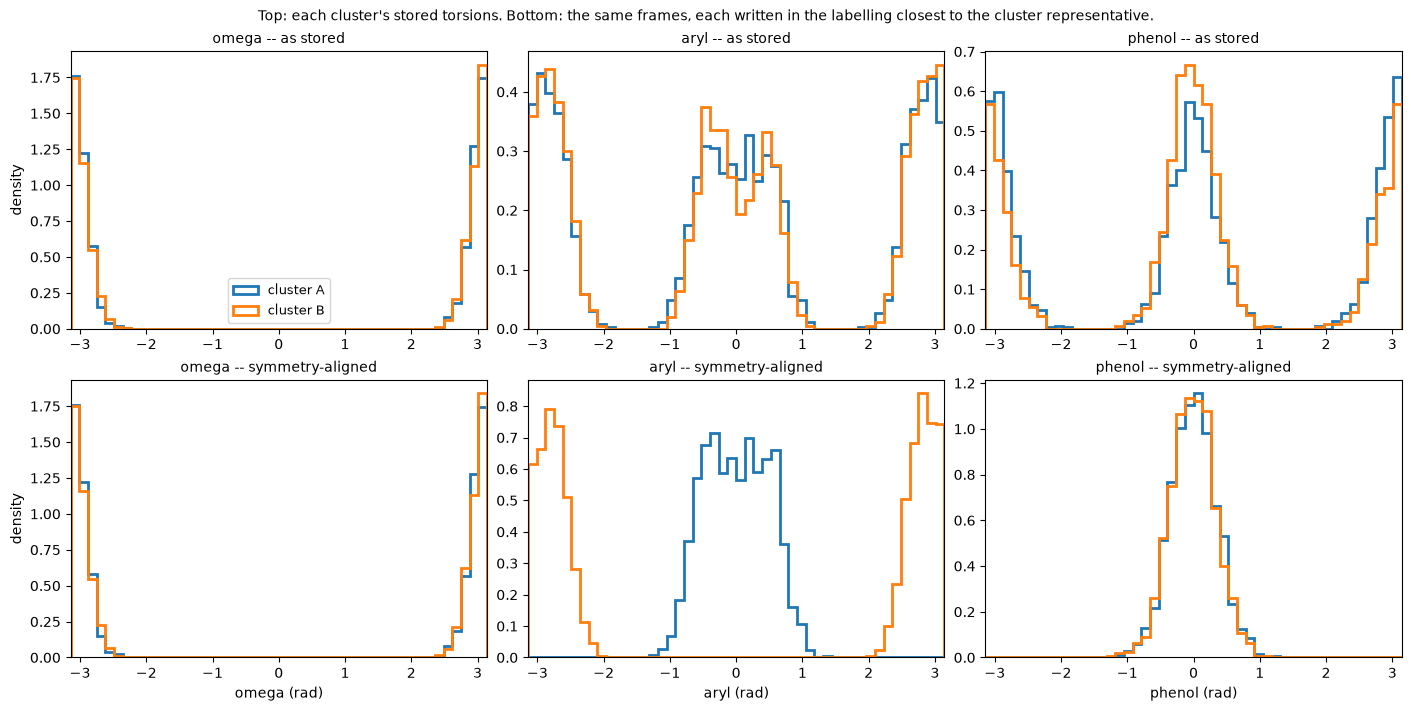

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), layout="constrained")
edges = np.linspace(-np.pi, np.pi, 49)
palette = plt.get_cmap("tab10")
for col, torsion in enumerate(names):
    for k, (name, c) in enumerate(groups.items()):
        raw_values = fit.theta_[fit.labels_ == c, col]
        axes[0, col].hist(raw_values, bins=edges, density=True, histtype="step", lw=2.0,
                          color=palette(k), label=f"cluster {name}")
        axes[1, col].hist(aligned[name]["angles"][:, col], bins=edges, density=True,
                          histtype="step", lw=2.0, color=palette(k), label=f"cluster {name}")
    for row, title in ((0, "as stored"), (1, "symmetry-aligned")):
        axes[row, col].set_xlim(-np.pi, np.pi)
        axes[row, col].set_title(f"{torsion} -- {title}", fontsize=10)
    axes[1, col].set_xlabel(f"{torsion} (rad)")
axes[0, 0].set_ylabel("density"); axes[1, 0].set_ylabel("density"); axes[0, 0].legend(fontsize=9)
fig.suptitle("Top: each cluster's stored torsions. Bottom: the same frames, each written in the "
             "labelling closest to the cluster representative.", fontsize=10)
plt.show()

### The table

Circular statistics on the symmetry-aligned angles: the mean DIRECTION, and the circular
standard deviation `sqrt(-2 ln R)` with `R` the resultant length. `mass` is the weighted fraction
of the whole ensemble, noise included; nothing is multiplied by the symmetry order.

In [18]:
def circular_mean(values):
    return float(np.arctan2(np.sin(values).mean(), np.cos(values).mean()))

def circular_std(values):
    resultant = np.hypot(np.sin(values).mean(), np.cos(values).mean())
    return float(np.sqrt(-2.0 * np.log(max(resultant, 1e-12))))

rows = []
for name, c in groups.items():
    values = aligned[name]["angles"]
    row = {"cluster": name}
    for col, torsion in enumerate(names):
        row[f"{torsion}_avg"] = np.rad2deg(circular_mean(values[:, col]))
        row[f"{torsion}_std"] = np.rad2deg(circular_std(values[:, col]))
    row["n_frames"] = int(values.shape[0])
    row["mass"] = float(fit.cluster_mass_[c])
    rows.append(row)
pd.DataFrame(rows).round(3)

,cluster,omega_avg,omega_std,aryl_avg,aryl_std,phenol_avg,phenol_std,n_frames,mass
0,A,179.872,12.314,0.031,27.762,-0.002,19.877,2056,0.514
1,B,179.946,12.671,-179.531,24.461,-0.765,19.349,1935,0.484


### A representative structure per cluster

An actual frame, never an average. The representative is the member with the strongest vote
(most of them are unanimous), and among those the one with the smallest summed **symmetry-aware**
distance to the other members, so a member written in the other labelling is not counted as far
away. Superposed and viewed down the molecule's flattest axis; nonpolar hydrogens removed, the
hydroxyl hydrogen kept because its orientation is the `phenol` torsion. Atom labels are the
trajectory's PDB names (C1 is the methyl carbon, C2 the carbonyl carbon).

13 atoms drawn, superposed: True


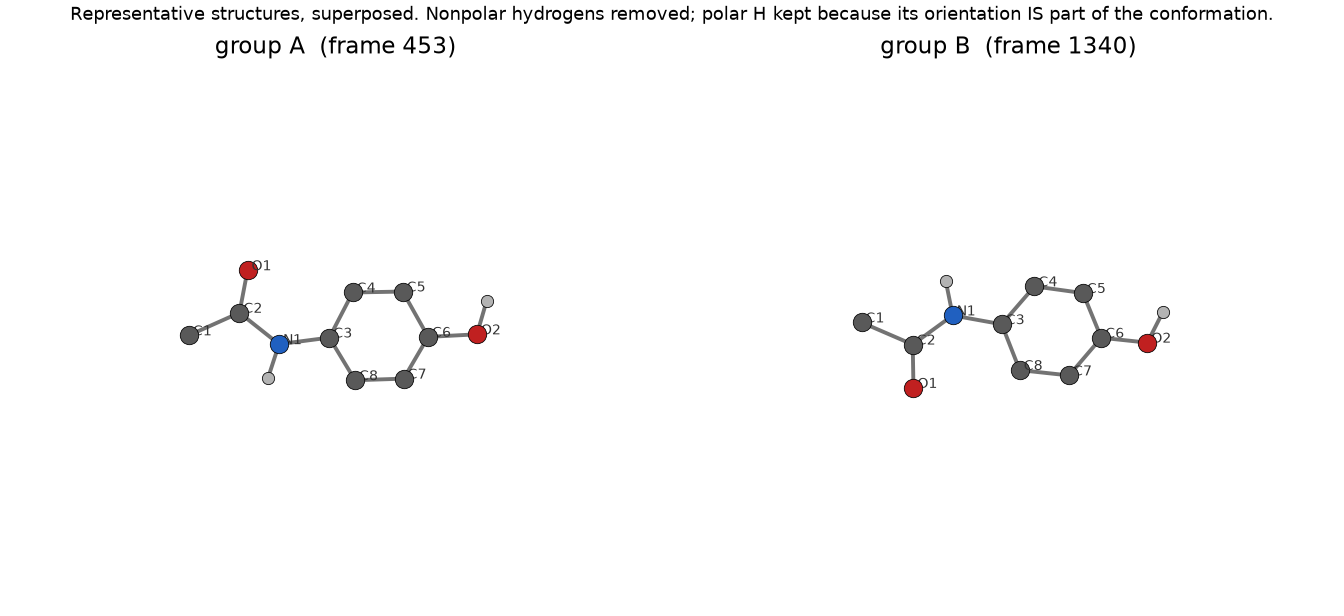

In [19]:
from md_tools.analysis import draw_representative_structures, strip_nonpolar_hydrogens

keep = strip_nonpolar_hydrogens(cmd)
info = draw_representative_structures(cmd, {name: reps[c] for name, c in groups.items()},
                                      output="representatives.png", atom_indices=keep)
print(f"{info['n_atoms_drawn']} atoms drawn, superposed: {info['aligned']}")
display(Image(filename="representatives.png"))

## What this does and does not establish

* **Structural, not thermodynamic.** Two configurations related by a graph automorphism are the
  same conformer under another naming. That does not make the populations of the two labellings
  equal in every simulation: an atom-specific restraint, an atom-indexed parameter or a REST2
  region covering one side of the ring breaks the energetic symmetry without changing the graph.
  Declare such a thing with `t_hdbscan(..., broken_by=["..."])`; it is recorded in the summary.
* **The answer here** is two clusters. Written in one labelling, cluster A has the carbonyl
  carbon (atom 1; PDB name C2) and the hydroxyl hydrogen (atom 17) on the SAME side of the
  ring's para axis -- `aryl` and `phenol` both near 0 degrees, each measured to the same side of
  the ring (atoms 5 and 6, PDB names C4 and C5); cluster B has them on OPPOSITE sides (`aryl` near
  180, `phenol` near 0). The structures above show it: the carbonyl points up in A and down in
  B, the hydroxyl hydrogen up in both. The previous workflow found four clusters and merged
  them into two groups after the fit; the comparison notebook puts the two side by side on these
  same frames, frame by frame.
* **A cluster is a density basin, not a metastable state.**